In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("data_for_ml.csv")
df.head()

,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
0,2.0,6.0,3.0,Male,Self Study,75.0,55.0
1,3.0,7.0,2.0,Female,Coaching,80.0,60.0
2,4.0,6.0,4.0,male,Self study,78.0,62.0
3,5.0,8.0,3.0,Femle,Group Study,85.0,70.0
4,6.0,7.0,5.0,Male,Self Study,88.0,72.0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Studied   56 non-null     float64
 1   Sleep_Hours     56 non-null     float64
 2   Internet_Usage  56 non-null     float64
 3   Gender          56 non-null     object 
 4   Study_Method    56 non-null     object 
 5   Attendance      56 non-null     float64
 6   Final_Score     56 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.2+ KB


Hours_Studied     1
Sleep_Hours       1
Internet_Usage    1
Gender            1
Study_Method      1
Attendance        1
Final_Score       1
dtype: int64

In [4]:
# Make safe copy
df = df.copy()

# Fill numeric missing values (including Final_Score)
df = df.fillna(df.mean(numeric_only=True))

# Drop any remaining nulls
df = df.dropna().copy()

# Remove duplicates
df = df.drop_duplicates().copy()

print(df.isnull().sum())

Hours_Studied     0
Sleep_Hours       0
Internet_Usage    0
Gender            0
Study_Method      0
Attendance        0
Final_Score       0
dtype: int64


In [5]:
le = LabelEncoder()

df.loc[:, 'Gender'] = le.fit_transform(df['Gender'])
df.loc[:, 'Study_Method'] = le.fit_transform(df['Study_Method'])

df.head()

,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
0,2.0,6.0,3.0,2,3,75.0,55.0
1,3.0,7.0,2.0,0,0,80.0,60.0
2,4.0,6.0,4.0,3,4,78.0,62.0
3,5.0,8.0,3.0,1,1,85.0,70.0
4,6.0,7.0,5.0,2,3,88.0,72.0


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df.drop("Final_Score", axis=1))

df_scaled = pd.DataFrame(X_scaled, columns=df.columns[:-1])
df_scaled['Final_Score'] = df['Final_Score'].values

# Final check
print(df_scaled.isnull().sum())

Hours_Studied     0
Sleep_Hours       0
Internet_Usage    0
Gender            0
Study_Method      0
Attendance        0
Final_Score       0
dtype: int64


In [7]:
features = [
    "Hours_Studied",
    "Sleep_Hours",
    "Internet_Usage",
    "Study_Method",
    "Attendance"
]

In [8]:
results = []

Feature: Hours_Studied
MSE: 16.333391984929055
R2: 0.8774995601130321


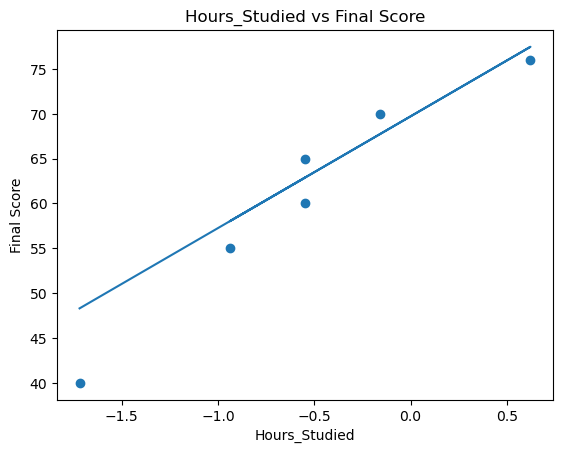

In [9]:
feature = "Hours_Studied"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Feature:", feature)
print("MSE:", mse)
print("R2:", r2)

results.append({"Feature": feature, "MSE": mse, "R2": r2})

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Hours_Studied vs Final Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Final Score")
plt.show()

Feature: Sleep_Hours
MSE: 48.75497319727481
R2: 0.634337701020439


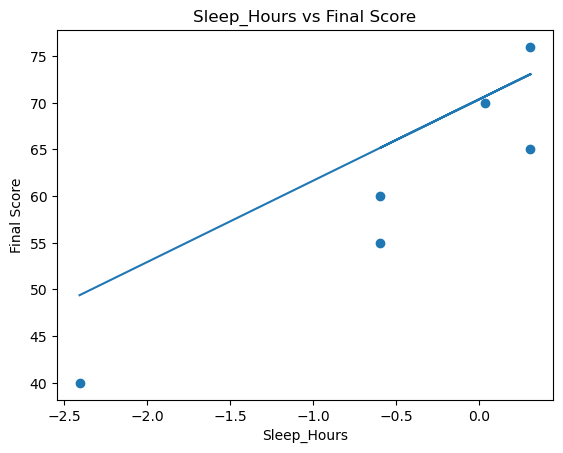

In [10]:
feature = "Sleep_Hours"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Feature:", feature)
print("MSE:", mse)
print("R2:", r2)

results.append({"Feature": feature, "MSE": mse, "R2": r2})

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Sleep_Hours vs Final Score")
plt.xlabel("Sleep_Hours")
plt.ylabel("Final Score")
plt.show()

Feature: Internet_Usage
MSE: 66.82614068947203
R2: 0.49880394482895984


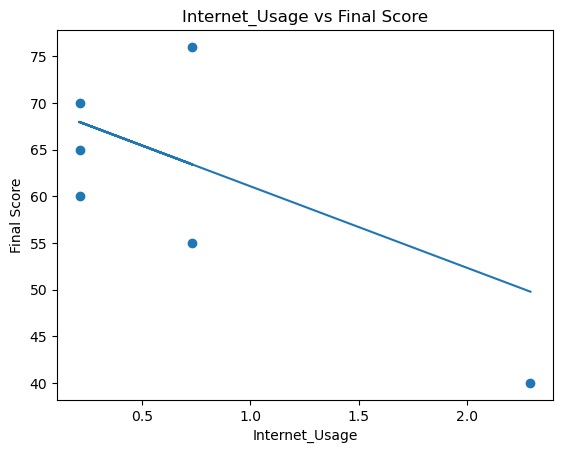

In [11]:
feature = "Internet_Usage"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Feature:", feature)
print("MSE:", mse)
print("R2:", r2)

results.append({"Feature": feature, "MSE": mse, "R2": r2})

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Internet_Usage vs Final Score")
plt.xlabel("Internet_Usage")
plt.ylabel("Final Score")
plt.show()

Feature: Study_Method
MSE: 261.5790318265765
R2: -0.9618427386993238


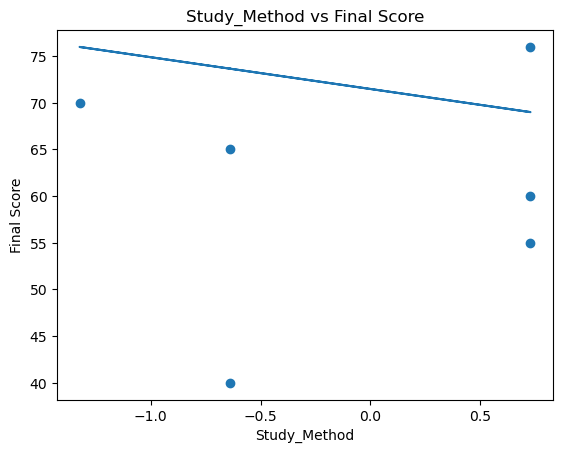

In [12]:
feature = "Study_Method"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model4 = LinearRegression()
model4.fit(X_train, y_train)

y_pred = model4.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Feature:", feature)
print("MSE:", mse)
print("R2:", r2)

results.append({"Feature": feature, "MSE": mse, "R2": r2})

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Study_Method vs Final Score")
plt.xlabel("Study_Method")
plt.ylabel("Final Score")
plt.show()

Feature: Attendance
MSE: 17.699945624809054
R2: 0.867250407813932


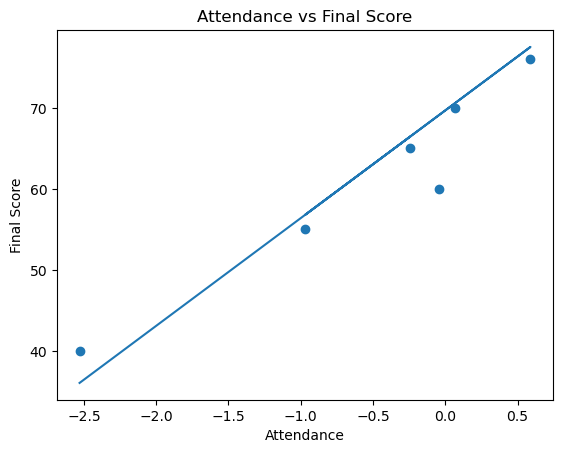

In [13]:
feature = "Attendance"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model5 = LinearRegression()
model5.fit(X_train, y_train)

y_pred = model5.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Feature:", feature)
print("MSE:", mse)
print("R2:", r2)

results.append({"Feature": feature, "MSE": mse, "R2": r2})

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Attendance vs Final Score")
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.show()

In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)

results_df

,Feature,MSE,R2
0,Hours_Studied,16.333392,0.877500
4,Attendance,17.699946,0.867250
1,Sleep_Hours,48.754973,0.634338
2,Internet_Usage,66.826141,0.498804
3,Study_Method,261.579032,-0.961843


In [15]:
best = results_df.iloc[0]

print("Best Feature:", best["Feature"])
print("Best R2:", best["R2"])
print("MSE:", best["MSE"])

Best Feature: Hours_Studied
Best R2: 0.8774995601130321
MSE: 16.333391984929055


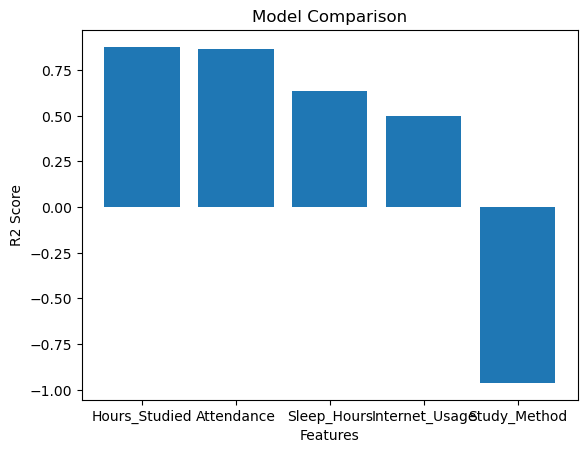

In [16]:
plt.bar(results_df["Feature"], results_df["R2"])
plt.title("Model Comparison")
plt.xlabel("Features")
plt.ylabel("R2 Score")
plt.show()